## 1. Setup and Imports
Importing libraries for data handling (pandas, numpy), the machine learning models (scikit-learn for Ridge and Random Forest, PyTorch for the LSTM), and evaluation metrics (RMSE, MAE, R2).

In [1]:
import pandas as pd
import numpy as np
import hopsworks
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
warnings.filterwarnings('ignore')
print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Data from Hopsworks Feature Store
Connecting to the Hopsworks Feature Store and reading back the historical AQI dataset. The data is sorted by timestamp because forecasting requires the records to be in correct time order before creating lag features.

In [2]:
project = hopsworks.login(
    api_key_value="gZvR3YByD8FXqMr8.jdC2AciLzhkSTATB8Vq0CUc3VtgU40SgVmjxakvvLSjrBK9BHFIh6GOyfZkcLLFk",
    project="PredictorAQI"
)
fs = project.get_feature_store()
fg = fs.get_feature_group(name="aqi_features", version=1)
df = fg.read()
df = df.sort_values("timestamp").reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
df.head()

2026-05-31 06:22:21,188 INFO: Initializing external client
2026-05-31 06:22:21,193 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-31 06:22:24,420 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32023
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.16s) 
Dataset shape: (4344, 18)


,timestamp,pm25,pm10,no2,o3,so2,co,temperature,humidity,wind,pressure,aqi,hour,day_of_week,month,is_weekend,aqi_category,city
0,2025-11-29 00:00:00+00:00,39.2,40.0,6.8,104.0,20.9,514.0,17.9,43.0,12.0,1015.9,110.0,0,5,11,1,unhealthy_sensitive,karachi
1,2025-11-29 01:00:00+00:00,39.7,40.5,14.7,95.0,22.0,686.0,17.5,43.0,12.0,1016.2,111.0,1,5,11,1,unhealthy_sensitive,karachi
2,2025-11-29 02:00:00+00:00,42.5,43.4,25.3,83.0,23.5,924.0,17.4,42.0,12.0,1016.7,118.0,2,5,11,1,unhealthy_sensitive,karachi
3,2025-11-29 03:00:00+00:00,46.3,47.1,31.1,81.0,25.2,1061.0,18.0,40.0,11.8,1017.2,128.0,3,5,11,1,unhealthy_sensitive,karachi
4,2025-11-29 04:00:00+00:00,47.3,48.1,27.5,97.0,27.5,1002.0,19.8,36.0,9.7,1017.7,130.0,4,5,11,1,unhealthy_sensitive,karachi


## 3. Initial Feature Engineering
Creating lag features (past AQI values such as 1, 24, and 72 hours ago) and rolling averages so the model can learn from recent history. The prediction target is the AQI at a future point, created by shifting the AQI column. Rows with missing values from shifting are dropped.

In [3]:
# Sort and set timestamp as the working index
df = df.sort_values("timestamp").reset_index(drop=True)

# --- Create lag features (past AQI values the model can look back on) ---
for lag in [1, 2, 3, 6, 12, 24, 48, 72]:
    df[f"aqi_lag_{lag}"] = df["aqi"].shift(lag)

# --- Rolling averages (smoothed recent trends) ---
df["aqi_roll_24"] = df["aqi"].shift(1).rolling(24).mean()
df["aqi_roll_72"] = df["aqi"].shift(1).rolling(72).mean()

# --- Create the TARGET: AQI 72 hours (3 days) into the future ---
df["target_aqi"] = df["aqi"].shift(-72)

# Drop rows with missing values created by shifting
df_model = df.dropna().reset_index(drop=True)

print(f"Rows after creating lags and target: {df_model.shape}")
print(f"\nNew columns added: {[c for c in df_model.columns if 'lag' in c or 'roll' in c or 'target' in c]}")
df_model[["timestamp", "aqi", "aqi_lag_1", "aqi_lag_24", "aqi_lag_72", "target_aqi"]].head()

Rows after creating lags and target: (4200, 29)

New columns added: ['aqi_lag_1', 'aqi_lag_2', 'aqi_lag_3', 'aqi_lag_6', 'aqi_lag_12', 'aqi_lag_24', 'aqi_lag_48', 'aqi_lag_72', 'aqi_roll_24', 'aqi_roll_72', 'target_aqi']


,timestamp,aqi,aqi_lag_1,aqi_lag_24,aqi_lag_72,target_aqi
0,2025-12-02 00:00:00+00:00,96.0,91.0,86.0,110.0,63.0
1,2025-12-02 01:00:00+00:00,93.0,96.0,83.0,111.0,64.0
2,2025-12-02 02:00:00+00:00,104.0,93.0,95.0,118.0,75.0
3,2025-12-02 03:00:00+00:00,124.0,104.0,123.0,128.0,91.0
4,2025-12-02 04:00:00+00:00,114.0,124.0,106.0,130.0,89.0


## 4. Train/Test Split (Time-Based)
Splitting the data by time rather than randomly: the model trains on the earliest 80% and is tested on the most recent 20%. This simulates real forecasting, where the model must predict a future period it has never seen.

In [4]:
# Features: weather, pollutants, time, and the lag/rolling features
feature_cols = [
    "pm25", "pm10", "no2", "o3", "so2", "co",
    "temperature", "humidity", "wind", "pressure",
    "hour", "day_of_week", "month", "is_weekend",
    "aqi_lag_1", "aqi_lag_2", "aqi_lag_3", "aqi_lag_6",
    "aqi_lag_12", "aqi_lag_24", "aqi_lag_48", "aqi_lag_72",
    "aqi_roll_24", "aqi_roll_72"
]

X = df_model[feature_cols]
y = df_model["target_aqi"]

# Time-based split: train on first 80%, test on last 20%
# (We DON'T shuffle — for time series, test must be the FUTURE relative to train)
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"Number of features: {X_train.shape[1]}")

Training set: 3360 rows
Test set: 840 rows
Number of features: 24


## 5. Baseline Models
Training Ridge Regression and Random Forest as initial baselines and evaluating them with RMSE, MAE, and R2.

In [5]:
results = {}

# --- Model 1: Ridge Regression (linear baseline) ---
# Ridge needs scaled features, so we standardize them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

results["Ridge"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, ridge_pred)),
    "MAE": mean_absolute_error(y_test, ridge_pred),
    "R2": r2_score(y_test, ridge_pred),
}

# --- Model 2: Random Forest (non-linear, tree-based) ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # trees don't need scaling
rf_pred = rf.predict(X_test)

results["RandomForest"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred)),
    "MAE": mean_absolute_error(y_test, rf_pred),
    "R2": r2_score(y_test, rf_pred),
}

# Show results
for name, m in results.items():
    print(f"{name:15s}  RMSE: {m['RMSE']:.2f}  MAE: {m['MAE']:.2f}  R2: {m['R2']:.3f}")

Ridge            RMSE: 23.57  MAE: 16.76  R2: -0.215
RandomForest     RMSE: 21.26  MAE: 15.96  R2: 0.012


## 6. Improved Feature Engineering
Expanding the feature set with additional lag features (including weekly lags), rolling averages and volatility, lagged weather/pollutant drivers, and cyclical encodings of hour and month. Cyclical encoding ensures that values like 23:00 and 00:00 are treated as close together.

In [6]:
# Start fresh from the time-sorted df
df2 = df.copy()

# More lag features, including around the 72h horizon and weekly (168h)
lags = [1, 2, 3, 6, 12, 24, 48, 71, 72, 73, 96, 120, 168]
for lag in lags:
    df2[f"aqi_lag_{lag}"] = df2["aqi"].shift(lag)

# Rolling means and std (recent level + recent volatility)
df2["aqi_roll_24"]  = df2["aqi"].shift(1).rolling(24).mean()
df2["aqi_roll_72"]  = df2["aqi"].shift(1).rolling(72).mean()
df2["aqi_roll_168"] = df2["aqi"].shift(1).rolling(168).mean()
df2["aqi_std_24"]   = df2["aqi"].shift(1).rolling(24).std()

# Lag the weather/pollutant drivers too (their recent values matter)
for col in ["pm25", "wind", "temperature"]:
    df2[f"{col}_lag_24"] = df2[col].shift(24)
    df2[f"{col}_lag_72"] = df2[col].shift(72)

# Cyclical encoding of hour and month (so 23:00 and 00:00 are "close")
df2["hour_sin"]  = np.sin(2 * np.pi * df2["hour"] / 24)
df2["hour_cos"]  = np.cos(2 * np.pi * df2["hour"] / 24)
df2["month_sin"] = np.sin(2 * np.pi * df2["month"] / 12)
df2["month_cos"] = np.cos(2 * np.pi * df2["month"] / 12)

# Target: AQI 72 hours ahead
df2["target_aqi"] = df2["aqi"].shift(-72)

df2_model = df2.dropna().reset_index(drop=True)
print(f"Rows after feature engineering: {df2_model.shape}")

Rows after feature engineering: (4104, 46)


## 7. Retraining with Improved Features
Retraining Ridge and Random Forest on the richer feature set to check whether the additional features improve performance.

In [7]:
# Build feature list: everything except non-feature columns
exclude = ["timestamp", "city", "aqi_category", "target_aqi", "aqi"]
feature_cols2 = [c for c in df2_model.columns if c not in exclude]

X2 = df2_model[feature_cols2]
y2 = df2_model["target_aqi"]

# Time-based split (same as before)
split_idx = int(len(df2_model) * 0.8)
X2_train, X2_test = X2[:split_idx], X2[split_idx:]
y2_train, y2_test = y2[:split_idx], y2[split_idx:]

results2 = {}

# Ridge (scaled)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)
ridge2 = Ridge(alpha=1.0)
ridge2.fit(X2_train_s, y2_train)
rp = ridge2.predict(X2_test_s)
results2["Ridge"] = {
    "RMSE": np.sqrt(mean_squared_error(y2_test, rp)),
    "MAE": mean_absolute_error(y2_test, rp),
    "R2": r2_score(y2_test, rp),
}

# Random Forest (tuned a bit)
rf2 = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf2.fit(X2_train, y2_train)
fp = rf2.predict(X2_test)
results2["RandomForest"] = {
    "RMSE": np.sqrt(mean_squared_error(y2_test, fp)),
    "MAE": mean_absolute_error(y2_test, fp),
    "R2": r2_score(y2_test, fp),
}

print(f"Features used: {len(feature_cols2)}")
for name, m in results2.items():
    print(f"{name:15s}  RMSE: {m['RMSE']:.2f}  MAE: {m['MAE']:.2f}  R2: {m['R2']:.3f}")

Features used: 41
Ridge            RMSE: 24.84  MAE: 17.63  R2: -0.332
RandomForest     RMSE: 21.37  MAE: 15.69  R2: 0.014


## 8. Testing a Shorter Forecast Horizon
Testing the model at a 24-hour-ahead horizon to investigate how forecast difficulty changes with the prediction distance. Shorter horizons are expected to be more predictable.

In [8]:
# Same features as df2, but target is now 24 hours ahead instead of 72
df24 = df2.copy()
df24["target_aqi"] = df24["aqi"].shift(-24)
df24_model = df24.dropna().reset_index(drop=True)

X24 = df24_model[feature_cols2]
y24 = df24_model["target_aqi"]

split_idx = int(len(df24_model) * 0.8)
X24_train, X24_test = X24[:split_idx], X24[split_idx:]
y24_train, y24_test = y24[:split_idx], y24[split_idx:]

# Random Forest
rf24 = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf24.fit(X24_train, y24_train)
p24 = rf24.predict(X24_test)

print("24-HOUR-AHEAD forecast:")
print(f"RMSE: {np.sqrt(mean_squared_error(y24_test, p24)):.2f}")
print(f"MAE:  {mean_absolute_error(y24_test, p24):.2f}")
print(f"R2:   {r2_score(y24_test, p24):.3f}")

24-HOUR-AHEAD forecast:
RMSE: 19.30
MAE:  14.01
R2:   0.190


## 9. Naive Persistence Baseline
Comparing the model against a naive baseline that simply assumes "AQI in the future equals AQI now." A useful model must outperform this baseline to prove it is learning real patterns.

In [9]:
# "Naive" forecast: assume AQI in 24h = AQI right now
# If our model can't beat this, it's not learning anything useful
naive_pred_24 = X24_test["aqi_lag_1"]  # AQI ~now as the prediction for 24h ahead

# But we need the "current" aqi, not lag_1 of target frame. Use actual current aqi:
current_aqi_24 = df24_model["aqi"].iloc[split_idx:]

print("NAIVE baseline (predict 'AQI in 24h = AQI now'):")
print(f"RMSE: {np.sqrt(mean_squared_error(y24_test, current_aqi_24)):.2f}")
print(f"MAE:  {mean_absolute_error(y24_test, current_aqi_24):.2f}")
print(f"R2:   {r2_score(y24_test, current_aqi_24):.3f}")

NAIVE baseline (predict 'AQI in 24h = AQI now'):
RMSE: 21.09
MAE:  14.20
R2:   0.033


## 10. Final Model Comparison (24-Hour Horizon)
Building the 24-hour-ahead dataset and training Ridge Regression and Random Forest on it. This horizon aligns with the project goal of forecasting upcoming days and performs meaningfully better than the longer horizon. Random Forest achieves the strongest scores.

In [10]:
# --- Build 24h-ahead dataset (reuse improved features from df2) ---
df_b = df2.copy()
df_b["target_aqi"] = df_b["aqi"].shift(-24)
df_b_model = df_b.dropna().reset_index(drop=True)

Xb = df_b_model[feature_cols2]
yb = df_b_model["target_aqi"]

split_idx = int(len(df_b_model) * 0.8)
Xb_train, Xb_test = Xb[:split_idx], Xb[split_idx:]
yb_train, yb_test = yb[:split_idx], yb[split_idx:]

final_results = {}

# --- Ridge ---
scaler_b = StandardScaler()
Xb_train_s = scaler_b.fit_transform(Xb_train)
Xb_test_s = scaler_b.transform(Xb_test)
ridge_b = Ridge(alpha=1.0)
ridge_b.fit(Xb_train_s, yb_train)
rp = ridge_b.predict(Xb_test_s)
final_results["Ridge"] = {
    "RMSE": np.sqrt(mean_squared_error(yb_test, rp)),
    "MAE": mean_absolute_error(yb_test, rp),
    "R2": r2_score(yb_test, rp),
}

# --- Random Forest ---
rf_b = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_b.fit(Xb_train, yb_train)
fp = rf_b.predict(Xb_test)
final_results["RandomForest"] = {
    "RMSE": np.sqrt(mean_squared_error(yb_test, fp)),
    "MAE": mean_absolute_error(yb_test, fp),
    "R2": r2_score(yb_test, fp),
}

print("24-HOUR-AHEAD model comparison:\n")
for name, m in final_results.items():
    print(f"{name:15s}  RMSE: {m['RMSE']:.2f}  MAE: {m['MAE']:.2f}  R2: {m['R2']:.3f}")

24-HOUR-AHEAD model comparison:

Ridge            RMSE: 20.31  MAE: 13.76  R2: 0.103
RandomForest     RMSE: 19.30  MAE: 14.01  R2: 0.190


## 11. Advanced Model: LSTM (PyTorch)
Training an LSTM neural network as the advanced deep-learning model, using sequences of past hours to predict future AQI. PyTorch was used instead of TensorFlow due to a dependency conflict between TensorFlow and Hopsworks. As expected on a dataset of this size, the LSTM overfits and does not beat the simpler Random Forest, showing that greater model complexity does not guarantee better results.

In [11]:
# Helper to build sequences for the LSTM
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

# Scale features for LSTM
scaler_lstm_b = StandardScaler()
Xb_scaled = scaler_lstm_b.fit_transform(Xb)

# Build sequences
SEQ_LEN = 24
Xb_seq, yb_seq = make_sequences(Xb_scaled, yb.values, SEQ_LEN)

split_idx_seq = int(len(Xb_seq) * 0.8)
Xb_tr, Xb_te = Xb_seq[:split_idx_seq], Xb_seq[split_idx_seq:]
yb_tr, yb_te = yb_seq[:split_idx_seq], yb_seq[split_idx_seq:]

Xb_tr_t = torch.tensor(Xb_tr, dtype=torch.float32)
yb_tr_t = torch.tensor(yb_tr, dtype=torch.float32).view(-1, 1)
Xb_te_t = torch.tensor(Xb_te, dtype=torch.float32)

class LSTMModel2(nn.Module):
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))

model_b = LSTMModel2(n_features=Xb_seq.shape[2])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_b.parameters(), lr=0.005)

train_ds = TensorDataset(Xb_tr_t, yb_tr_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

print("Training LSTM (24h)...")
for epoch in range(150):
    model_b.train()
    for xb_, yb_ in train_dl:
        optimizer.zero_grad()
        loss = criterion(model_b(xb_), yb_)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/150  loss: {loss.item():.2f}")

model_b.eval()
with torch.no_grad():
    lstm_pred_b = model_b(Xb_te_t).numpy().flatten()

final_results["LSTM"] = {
    "RMSE": np.sqrt(mean_squared_error(yb_te, lstm_pred_b)),
    "MAE": mean_absolute_error(yb_te, lstm_pred_b),
    "R2": r2_score(yb_te, lstm_pred_b),
}

print("\nFINAL 24-HOUR comparison:\n")
for name, m in final_results.items():
    print(f"{name:15s}  RMSE: {m['RMSE']:.2f}  MAE: {m['MAE']:.2f}  R2: {m['R2']:.3f}")

Training LSTM (24h)...
Epoch 50/150  loss: 111.29
Epoch 100/150  loss: 57.00
Epoch 150/150  loss: 20.32

FINAL 24-HOUR comparison:

Ridge            RMSE: 20.31  MAE: 13.76  R2: 0.103
RandomForest     RMSE: 19.30  MAE: 14.01  R2: 0.190
LSTM             RMSE: 25.99  MAE: 18.90  R2: -0.465


## 12. Save Best Model to the Model Registry
Random Forest was the best-performing model across RMSE, MAE, and R2, so it is saved to the Hopsworks Model Registry along with its scaler and feature list. This lets the dashboard and automated pipeline load and reuse the exact trained model without retraining.

In [12]:
import joblib
import os
from hsml.schema import Schema
from hsml.model_schema import ModelSchema

# --- Save the model and scaler locally first ---
os.makedirs("aqi_model", exist_ok=True)
joblib.dump(rf_b, "aqi_model/random_forest_model.pkl")
joblib.dump(scaler_b, "aqi_model/scaler.pkl")

# Save the feature list so the dashboard knows what inputs the model expects
import json
with open("aqi_model/feature_cols.json", "w") as f:
    json.dump(feature_cols2, f)

# --- Define the model schema (input features + output) ---
input_schema = Schema(Xb_train)
output_schema = Schema(yb_train)
model_schema = ModelSchema(input_schema=input_schema, output_schema=output_schema)

# --- Register the model in Hopsworks Model Registry ---
mr = project.get_model_registry()

aqi_model = mr.python.create_model(
    name="aqi_random_forest",
    metrics={
        "rmse": final_results["RandomForest"]["RMSE"],
        "mae": final_results["RandomForest"]["MAE"],
        "r2": final_results["RandomForest"]["R2"],
    },
    model_schema=model_schema,
    description="Random Forest model predicting Karachi AQI 24h ahead (best of Ridge/RF/LSTM)",
)

aqi_model.save("aqi_model")
print("Model saved to Hopsworks Model Registry!")

  0%|          | 0/6 [00:00<?, ?it/s]

Uploading C:\Users\ayesh\Desktop\AQI-predictor\notebooks\aqi_model/feature_cols.json: 0.000%|          | 0/529…

Uploading C:\Users\ayesh\Desktop\AQI-predictor\notebooks\aqi_model/random_forest_model.pkl: 0.000%|          |…

Uploading C:\Users\ayesh\Desktop\AQI-predictor\notebooks\aqi_model/scaler.pkl: 0.000%|          | 0/2287 elaps…

Uploading C:\Users\ayesh\Desktop\AQI-predictor\notebooks\model_schema.json: 0.000%|          | 0/3303 elapsed<…

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/32023/models/aqi_random_forest/3
Model saved to Hopsworks Model Registry!


## 13. Model Explainability with SHAP
Using SHAP to identify which features most influence the model's predictions. PM2.5 is by far the dominant driver, followed by the recent AQI trend (rolling averages) and seasonality (month), confirming the model relies on physically sensible factors.

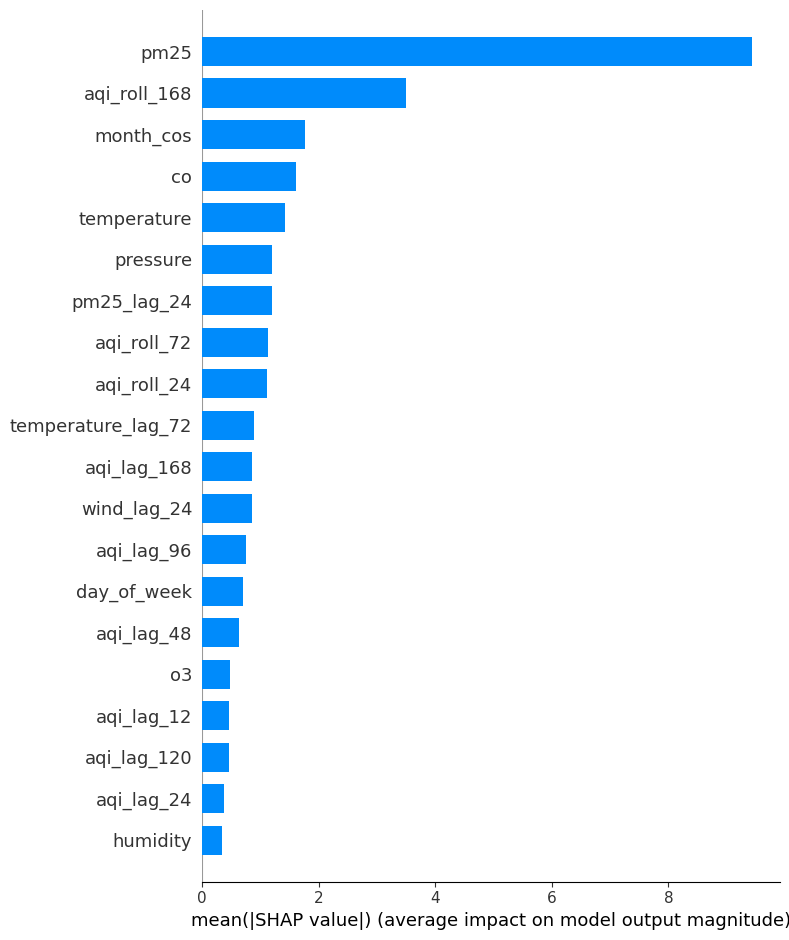

Top 10 most important features:
  pm25                  9.441
  aqi_roll_168          3.499
  month_cos             1.763
  co                    1.615
  temperature           1.427
  pressure              1.193
  pm25_lag_24           1.191
  aqi_roll_72           1.138
  aqi_roll_24           1.105
  temperature_lag_72    0.886


In [13]:
import shap
import matplotlib.pyplot as plt

# Use a sample of the test set for speed (SHAP can be slow on all rows)
X_sample = Xb_test.iloc[:200]

# TreeExplainer is fast and exact for tree models like Random Forest
explainer = shap.TreeExplainer(rf_b)
shap_values = explainer.shap_values(X_sample)

# --- Summary bar plot: average importance of each feature ---
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top 10 features by importance
import numpy as np
mean_abs = np.abs(shap_values).mean(axis=0)
importance = sorted(zip(feature_cols2, mean_abs), key=lambda x: x[1], reverse=True)
print("Top 10 most important features:")
for feat, val in importance[:10]:
    print(f"  {feat:20s}  {val:.3f}")

## 14. SHAP Directional Effects
The beeswarm plot shows the direction of each feature's effect. High PM2.5 values push the predicted AQI upward, while higher wind speeds push it downward, confirming the model has learned realistic relationships.

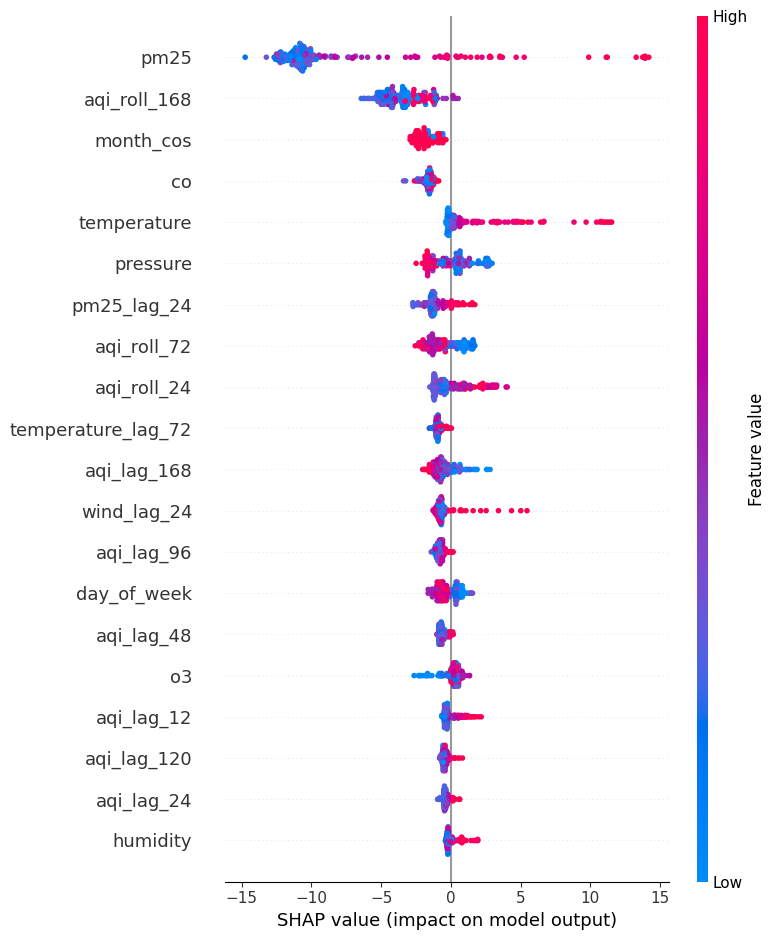

In [14]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()